# Independent t-Test: Smartphone Thermal Analysis  <hr style="border:2.5px solid #126782"></hr>

<b>Angel Grace R. Macawili</b>
<br>Computer Engineering Technology

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.proportion import proportions_ztest

In [63]:
# Load the dataset
df_raw = pd.read_csv(r"D:\AGRMacawili(lab act)\ENDTERM_EXAM\dataset\smartphone_battery_drain_dataset.csv",
                     delimiter = ",")
initial_count = len(df_raw)
df

,App_Running,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Network_Type,Brightness_Level_%,RAM_Usage_MB,Charging_State,Usage_Mode
0,Facebook,70.779244,55.550655,34.301005,6.020228,5G,57,2941.852469,Charging,Gaming
1,PUBG,90.044282,10.506832,35.607895,13.372379,WiFi,10,1930.581458,Not Charging,Social Media
2,Maps,75.197224,38.529769,43.312775,3.514550,5G,37,2169.828899,Charging,Social Media
3,WhatsApp,114.762495,26.898454,33.795197,6.728475,WiFi,33,2329.369145,Charging,Browsing
4,Facebook,52.214675,36.862349,41.089636,19.134837,5G,25,2175.002939,Charging,Video Streaming
...,...,...,...,...,...,...,...,...,...,...
2498,Instagram,56.488493,24.271686,40.431544,13.258253,WiFi,63,2187.176944,Not Charging,Gaming
2499,WhatsApp,80.865618,33.550557,24.552252,17.555962,5G,17,2653.751518,Charging,Gaming
2500,Chrome,64.043076,48.248489,26.177555,12.686444,WiFi,97,2734.017392,Not Charging,Browsing
2501,PUBG,85.989414,51.872556,29.039868,10.659386,4G,69,2451.633483,Charging,Browsing


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2498 entries, 0 to 2502
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   App_Running            2498 non-null   object 
 1   Screen_On_Time_min     2498 non-null   float64
 2   CPU_Usage_%            2493 non-null   float64
 3   Battery_Temperature_C  2498 non-null   float64
 4   Battery_Drop_Per_Hour  2498 non-null   float64
 5   Network_Type           2498 non-null   object 
 6   Brightness_Level_%     2498 non-null   int64  
 7   RAM_Usage_MB           2498 non-null   float64
 8   Charging_State         2498 non-null   object 
 9   Usage_Mode             2498 non-null   object 
dtypes: float64(5), int64(1), object(4)
memory usage: 214.7+ KB


In [65]:
#Cleaning the Data
df = df_raw.dropna(subset=['Battery_Temperature_C', 'Charging_State'])
final_count = len(df)
cleared_count = initial_count - final_count

print(f"--- Data Cleaning Report ---")
print(f"Initial records: {initial_count}")
print(f"Records cleared (due to missing values): {cleared_count}")
print(f"Final records used for analysis: {final_count}")

--- Data Cleaning Report ---
Initial records: 2503
Records cleared (due to missing values): 5
Final records used for analysis: 2498


In [66]:
# Separate into groups
charging = df[df['Charging_State'] == 'Charging']['Battery_Temperature_C']
not_charging = df[df['Charging_State'] == 'Not Charging']['Battery_Temperature_C']

# Summary Statistics

In [67]:
summary = df.groupby('Charging_State')['Battery_Temperature_C'].agg(['mean', 'std', 'count', 'min', 'max'])
print("\n--- Summary Statistics ---")
print(summary)


--- Summary Statistics ---
                     mean       std  count   min        max
Charging_State                                             
Charging        35.018106  5.183416   1311  20.0  52.720325
Not Charging    34.957694  5.111995   1187  20.0  51.990637


# Boxplot

C:\Users\ACER\AppData\Local\Temp\ipykernel_32712\1317012966.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([charging, not_charging], labels=['Charging', 'Not Charging'],


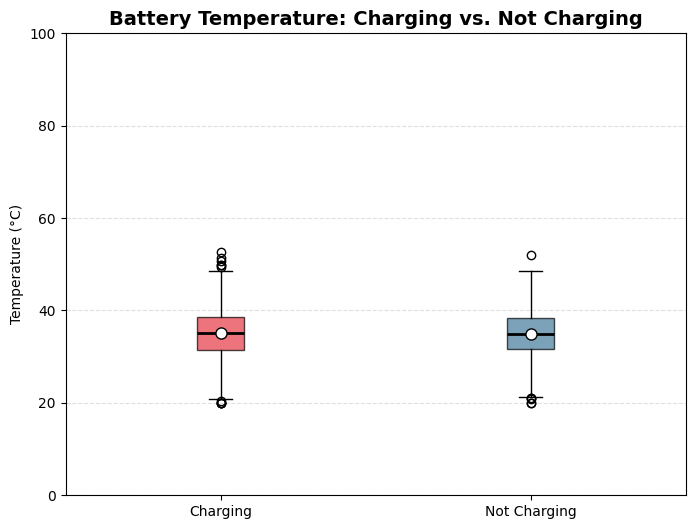

In [68]:
plt.figure(figsize=(8, 6))
box = plt.boxplot([charging, not_charging], labels=['Charging', 'Not Charging'], 
                  patch_artist=True, showmeans=True,
                  meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                  medianprops=dict(color='black', linewidth=2))

colors = ['#E63946', '#457B9D'] # Red for Charging, Blue for Not Charging
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Battery Temperature: Charging vs. Not Charging', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)')
plt.ylim(0, 100) # Force Y-axis to 100
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Normality Test

In [69]:
# p > 0.05 means the data follows a bell curve (normal)
p_norm_charging = stats.shapiro(charging).pvalue
p_norm_not_charging = stats.shapiro(not_charging).pvalue
print(f"\n--- Normality (p-values) ---")
print(f"Charging: {p_norm_charging:.4f}")
print(f"Not Charging: {p_norm_not_charging:.4f}")

if p_norm_charging > 0.05 and p_norm_not_charging> 0.05:
    print("Interpretation: Both groups follow a normal distribution. Parametric tests such as the t-test are appropriate.")
else:
    print("Interpretation: One or both groups are not normally distributed. A non-parametric test may be more appropriate.")


--- Normality (p-values) ---
Charging: 0.7749
Not Charging: 0.5119
Interpretation: Both groups follow a normal distribution. Parametric tests such as the t-test are appropriate.


# Variance Test

In [70]:
# p > 0.05 means both groups have a similar spread
levene_p = stats.levene(charging, not_charging).pvalue
print(f"\n--- Variance Test (p-value) ---")
print(f"Levene's Test: {levene_p:.4f}")

if levene_p > 0.05:
    print("Interpretation: Variances between the two groups are equal.")
else:
    print("Interpretation: Variances between the two groups are significantly different.")


--- Variance Test (p-value) ---
Levene's Test: 0.4515
Interpretation: Variances between the two groups are equal.


# Independent Two-Sample t-Test

In [71]:
# Tests if Charging Temp > Not Charging Temp
t_stat, t_p = stats.ttest_ind(charging, not_charging, equal_var=(levene_p > 0.05), alternative='greater')
print(f"\n--- t-Test Results ---")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {t_p:.4f}")

if t_p < 0.05:
    print("Interpretation: The battery temperature while charging is significantly higher than when not charging.")
else:
    print("Interpretation: There is no statistically significant difference in battery temperature between charging and not charging states.")


--- t-Test Results ---
t-statistic: 0.2928
p-value: 0.3848
Interpretation: There is no statistically significant difference in battery temperature between charging and not charging states.


# Power Analysis

In [72]:
n1, n2 = len(charging), len(not_charging)
diff = charging.mean() - not_charging.mean()
combined_sd = np.sqrt((charging.var() + not_charging.var()) / 2)
cohen_d = diff / combined_sd

power_obj = TTestIndPower()
stat_power = power_obj.solve_power(effect_size=cohen_d, nobs1=n1, ratio=n2/n1, alpha=0.05)

print(f"\n--- Power Analysis ---")
print(f"Effect Size (Cohen's d): {cohen_d:.4f}")
print(f"Calculated Power: {stat_power:.4f}")

if stat_power >= 0.8:
    print("Interpretation: The statistical test has sufficient power to detect a meaningful difference.")
else:
    print("Interpretation: The statistical power is low, meaning the test may not reliably detect small differences.")


--- Power Analysis ---
Effect Size (Cohen's d): 0.0117
Calculated Power: 0.0599
Interpretation: The statistical power is low, meaning the test may not reliably detect small differences.


# Proportion Test

In [73]:
threshold = 38.0
count_hot = [(charging > threshold).sum(), (not_charging > threshold).sum()]
z_stat, prop_p = proportions_ztest(count_hot, [n1, n2], alternative='larger')

print(f"\n--- Proportion Test Results ---")
print(f"Charging Hot Prop: {count_hot[0]/n1:.4f}")
print(f"Not Charging Hot Prop:{count_hot[1]/n2:.4f}")
print(f"p-value: {prop_p:.4f}")

if prop_p < 0.05:
    print("Interpretation: Charging significantly increases the probability of the battery exceeding 38°C.")
else:
    print("Interpretation: Charging does not significantly increase the probability of the battery exceeding 38°C.")


--- Proportion Test Results ---
Charging Hot Prop: 0.2853
Not Charging Hot Prop:0.2789
p-value: 0.3608
Interpretation: Charging does not significantly increase the probability of the battery exceeding 38°C.


# Conclusion

These results suggest that battery temperature may be influenced more by smartphone usage and running applications rather than by the charging state itself.